In [1]:
# Phase 5 — Integration
# Cell 1: Project Setup

from pathlib import Path
import json
import os

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

PROJECT_ROOT = Path("/Volumes/Utkash SSD/SIH26143")

MODEL_PATH = PROJECT_ROOT / "best_oil_spill_unet.pth"

PHASE2_RESULT = PROJECT_ROOT / "spill_detection_result.geojson"
PHASE3_RESULT = PROJECT_ROOT / "phase3_hindcast_result.json"
PHASE4_RESULT = PROJECT_ROOT / "phase4_ais_attribution_result.json"

# ---------------------------------------------------------
# Verify required files
# ---------------------------------------------------------

required_files = {
    "Project": PROJECT_ROOT,
    "Segmentation model": MODEL_PATH,
    "Phase 2 result": PHASE2_RESULT,
    "Phase 3 result": PHASE3_RESULT,
    "Phase 4 result": PHASE4_RESULT,
}

print("=" * 65)
print("PHASE 5 — INTEGRATION SETUP")
print("=" * 65)

for name, path in required_files.items():
    status = "✓ FOUND" if path.exists() else "✗ MISSING"
    print(f"{name:<22} : {status}")
    print(f"  {path}")

print("=" * 65)

# ---------------------------------------------------------
# Basic validation
# ---------------------------------------------------------

missing = [
    name
    for name, path in required_files.items()
    if not path.exists()
]

if missing:
    print("\n⚠️ Missing files:")
    for item in missing:
        print(f"  - {item}")
else:
    print("\n✅ All Phase 1–4 artifacts are available.")
    print("🚀 Ready to build the integrated pipeline.")

PHASE 5 — INTEGRATION SETUP
Project                : ✓ FOUND
  /Volumes/Utkash SSD/SIH26143
Segmentation model     : ✓ FOUND
  /Volumes/Utkash SSD/SIH26143/best_oil_spill_unet.pth
Phase 2 result         : ✓ FOUND
  /Volumes/Utkash SSD/SIH26143/spill_detection_result.geojson
Phase 3 result         : ✓ FOUND
  /Volumes/Utkash SSD/SIH26143/phase3_hindcast_result.json
Phase 4 result         : ✓ FOUND
  /Volumes/Utkash SSD/SIH26143/phase4_ais_attribution_result.json

✅ All Phase 1–4 artifacts are available.
🚀 Ready to build the integrated pipeline.


In [2]:
# Phase 5 — Integration
# Cell 2: Load Exact Phase 1 Segmentation Model

import torch
import torch.nn as nn

# ---------------------------------------------------------
# Device
# ---------------------------------------------------------

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")


# ---------------------------------------------------------
# Exact Phase 1 U-Net architecture
# ---------------------------------------------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        # IMPORTANT:
        # Phase 1 checkpoint uses "output", not "final"
        self.output = nn.Conv2d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)


# ---------------------------------------------------------
# Create model
# ---------------------------------------------------------

model = UNet(
    in_channels=2,
    out_channels=1
).to(DEVICE)


# ---------------------------------------------------------
# Load saved Phase 1 checkpoint
# ---------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)


# ---------------------------------------------------------
# Extract model weights
# ---------------------------------------------------------

if (
    isinstance(checkpoint, dict)
    and "model_state_dict" in checkpoint
):
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint


# ---------------------------------------------------------
# Load weights
# ---------------------------------------------------------

model.load_state_dict(state_dict)


# ---------------------------------------------------------
# Inference mode + freeze
# ---------------------------------------------------------

model.eval()

for param in model.parameters():
    param.requires_grad = False


# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("=" * 65)
print("SEGMENTATION MODEL LOADED")
print("=" * 65)

print(f"Checkpoint : {MODEL_PATH}")
print(f"Device     : {DEVICE}")
print(
    f"Parameters : "
    f"{sum(p.numel() for p in model.parameters()):,}"
)
print("Training   : DISABLED")
print("Inference  : READY")
print("=" * 65)

Using device: mps
SEGMENTATION MODEL LOADED
Checkpoint : /Volumes/Utkash SSD/SIH26143/best_oil_spill_unet.pth
Device     : mps
Parameters : 1,926,721
Training   : DISABLED
Inference  : READY


In [3]:
# Phase 5 — Integration
# Cell 3: SAR Image Loader + Preprocessing

import numpy as np
import rasterio
import torch

# ---------------------------------------------------------
# Select sample SAR image
# ---------------------------------------------------------

SAMPLE_IMAGE = PROJECT_ROOT / "Oil" / "00000.tif"

print("=" * 65)
print("SAR IMAGE LOADER")
print("=" * 65)

print(f"Image: {SAMPLE_IMAGE}")

if not SAMPLE_IMAGE.exists():
    raise FileNotFoundError(
        f"SAR image not found: {SAMPLE_IMAGE}"
    )

# ---------------------------------------------------------
# Read SAR image
# ---------------------------------------------------------

with rasterio.open(SAMPLE_IMAGE) as src:

    sar = src.read()
    transform = src.transform
    crs = src.crs
    bounds = src.bounds

print(f"Raw shape : {sar.shape}")
print(f"Data type : {sar.dtype}")
print(f"CRS      : {crs}")

# ---------------------------------------------------------
# Verify 2-band VV/VH input
# ---------------------------------------------------------

if sar.shape[0] != 2:
    raise ValueError(
        f"Expected 2 SAR bands (VV, VH), "
        f"but found {sar.shape[0]} bands."
    )

# ---------------------------------------------------------
# Convert to float32
# ---------------------------------------------------------

sar = sar.astype(np.float32)

# ---------------------------------------------------------
# Per-band normalization
# ---------------------------------------------------------

normalized = np.zeros_like(sar, dtype=np.float32)

for i in range(2):

    band = sar[i]

    mean = np.nanmean(band)
    std = np.nanstd(band)

    if std == 0:
        raise ValueError(
            f"Band {i} has zero standard deviation."
        )

    normalized[i] = (
        (band - mean) / (std + 1e-8)
    )

# ---------------------------------------------------------
# Replace invalid values
# ---------------------------------------------------------

normalized = np.nan_to_num(
    normalized,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ---------------------------------------------------------
# Convert to PyTorch tensor
# ---------------------------------------------------------

image_tensor = torch.from_numpy(
    normalized
).unsqueeze(0).to(DEVICE)

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("=" * 65)
print("PREPROCESSING COMPLETE")
print("=" * 65)

print(f"Tensor shape : {tuple(image_tensor.shape)}")
print(f"Device       : {image_tensor.device}")
print(f"Min value    : {image_tensor.min().item():.4f}")
print(f"Max value    : {image_tensor.max().item():.4f}")
print(f"Mean         : {image_tensor.mean().item():.4f}")
print(f"Std          : {image_tensor.std().item():.4f}")

print("=" * 65)

SAR IMAGE LOADER
Image: /Volumes/Utkash SSD/SIH26143/Oil/00000.tif
Raw shape : (2, 2048, 2048)
Data type : float32
CRS      : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


ERROR 1: PROJ: internal_proj_identify: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


PREPROCESSING COMPLETE
Tensor shape : (1, 2, 2048, 2048)
Device       : mps:0
Min value    : -11.0111
Max value    : 16.6033
Mean         : 0.0000
Std          : 1.0000


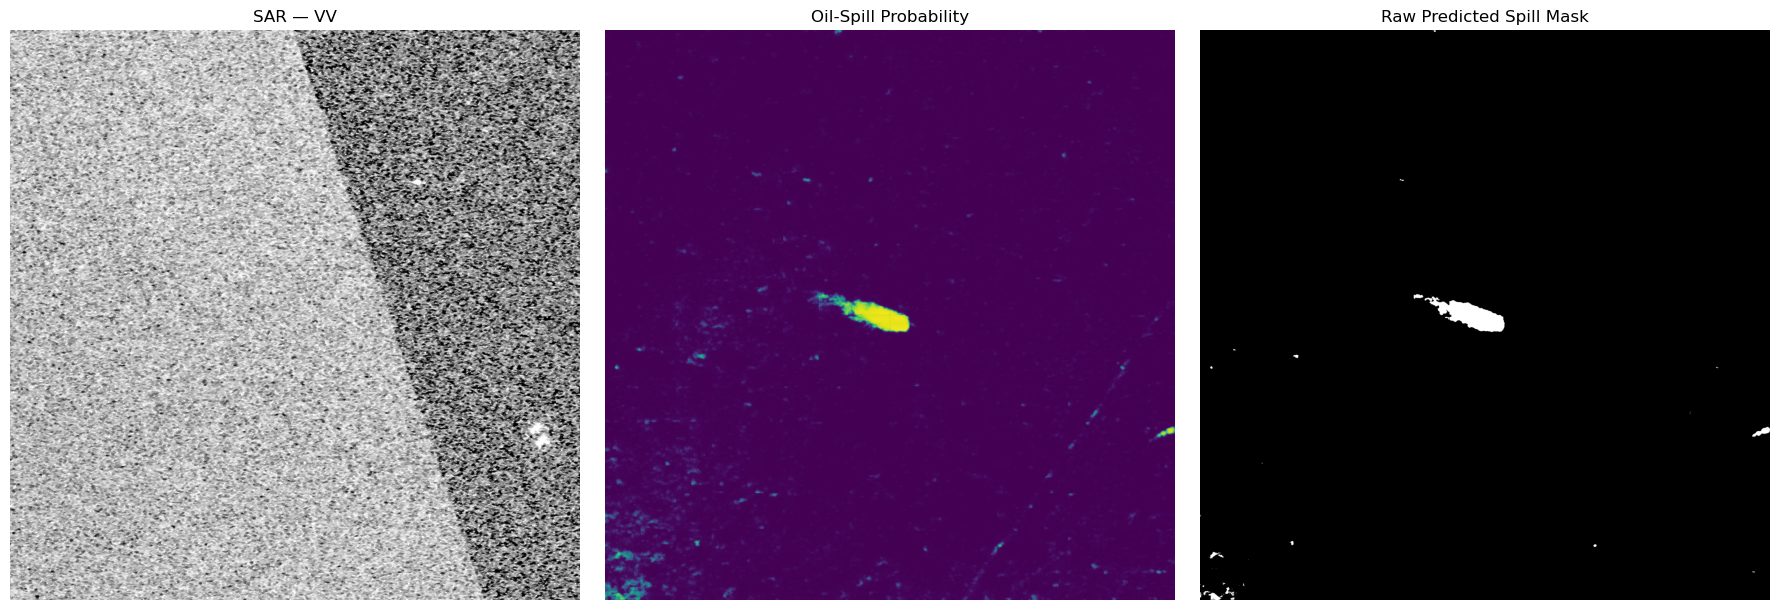

EXACT PHASE 2 INFERENCE COMPLETE
Input image       : 2048 × 2048
Patch size        : 256 × 256
Stride            : 128
Probability range : 0.0001 → 0.9917
Threshold         : 0.5
Predicted pixels  : 20,513
Total pixels      : 4,194,304
Raw coverage      : 0.4891%


In [4]:
# Phase 5 — Integration
# Cell 4: Exact Phase 2 Segmentation Inference

import numpy as np
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------
# Exact Phase 2 configuration
# ---------------------------------------------------------

PATCH_SIZE = 256
STRIDE = 128
PREDICTION_THRESHOLD = 0.5

# ---------------------------------------------------------
# Exact Phase 2 preprocessing
# Whole image → 1st/99th percentile → [0,1]
# ---------------------------------------------------------

def preprocess_sar_image(image):
    image = image.copy().astype(np.float32)

    for band in range(image.shape[0]):

        low = np.percentile(
            image[band],
            1
        )

        high = np.percentile(
            image[band],
            99
        )

        image[band] = np.clip(
            (image[band] - low)
            / (high - low + 1e-6),
            0,
            1
        )

    return image


# ---------------------------------------------------------
# Preprocess the loaded SAR image
# ---------------------------------------------------------

processed_image = preprocess_sar_image(sar)

# ---------------------------------------------------------
# Exact Phase 2 overlapping inference
# ---------------------------------------------------------

def predict_full_image(
    model,
    image,
    patch_size=256,
    stride=128,
    device=DEVICE
):

    channels, height, width = image.shape

    probability_sum = np.zeros(
        (height, width),
        dtype=np.float32
    )

    prediction_count = np.zeros(
        (height, width),
        dtype=np.float32
    )

    model.eval()

    with torch.no_grad():

        for y in range(
            0,
            height - patch_size + 1,
            stride
        ):

            for x in range(
                0,
                width - patch_size + 1,
                stride
            ):

                patch = image[
                    :,
                    y:y + patch_size,
                    x:x + patch_size
                ]

                tensor = torch.from_numpy(
                    patch
                ).float()

                tensor = tensor.unsqueeze(
                    0
                ).to(device)

                logits = model(tensor)

                probabilities = torch.sigmoid(
                    logits
                )

                probabilities = (
                    probabilities[0, 0]
                    .cpu()
                    .numpy()
                )

                probability_sum[
                    y:y + patch_size,
                    x:x + patch_size
                ] += probabilities

                prediction_count[
                    y:y + patch_size,
                    x:x + patch_size
                ] += 1

    probability_map = (
        probability_sum
        / np.maximum(
            prediction_count,
            1
        )
    )

    prediction_mask = (
        probability_map
        >= PREDICTION_THRESHOLD
    ).astype(np.uint8)

    return probability_map, prediction_mask


# ---------------------------------------------------------
# Run exact Phase 2 inference
# ---------------------------------------------------------

probability_map, prediction_mask = predict_full_image(
    model,
    processed_image,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    device=DEVICE
)

# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------

positive_pixels = int(
    prediction_mask.sum()
)

total_pixels = int(
    prediction_mask.size
)

coverage = (
    prediction_mask.mean()
    * 100
)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

axes[0].imshow(
    processed_image[0],
    cmap="gray"
)

axes[0].set_title(
    "SAR — VV"
)

axes[0].axis("off")


axes[1].imshow(
    probability_map,
    cmap="viridis",
    vmin=0,
    vmax=1
)

axes[1].set_title(
    "Oil-Spill Probability"
)

axes[1].axis("off")


axes[2].imshow(
    prediction_mask,
    cmap="gray"
)

axes[2].set_title(
    "Raw Predicted Spill Mask"
)

axes[2].axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("=" * 65)
print("EXACT PHASE 2 INFERENCE COMPLETE")
print("=" * 65)

print(
    f"Input image       : "
    f"{height if 'height' in globals() else sar.shape[1]} "
    f"× "
    f"{width if 'width' in globals() else sar.shape[2]}"
)

print(
    f"Patch size        : "
    f"{PATCH_SIZE} × {PATCH_SIZE}"
)

print(
    f"Stride            : "
    f"{STRIDE}"
)

print(
    f"Probability range : "
    f"{probability_map.min():.4f} → "
    f"{probability_map.max():.4f}"
)

print(
    f"Threshold         : "
    f"{PREDICTION_THRESHOLD}"
)

print(
    f"Predicted pixels  : "
    f"{positive_pixels:,}"
)

print(
    f"Total pixels      : "
    f"{total_pixels:,}"
)

print(
    f"Raw coverage      : "
    f"{coverage:.4f}%"
)

print("=" * 65)

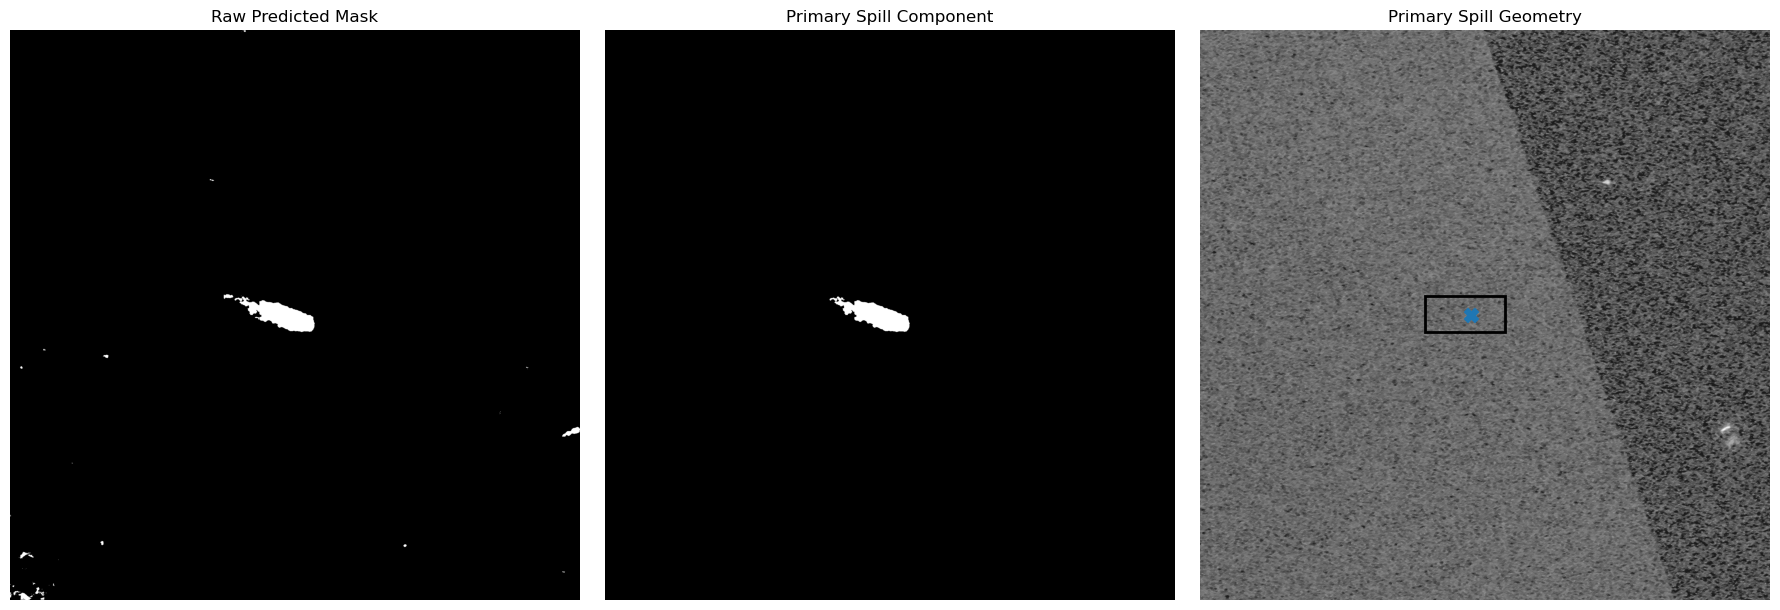

PRIMARY SPILL EXTRACTION COMPLETE
Components detected       : 58
Valid components (>=500px): 3
Primary spill area         : 16,549 pixels
Bounding box               : 288 × 128
Centroid (pixel)           : (972.88, 1025.24)
Aspect ratio               : 2.25


In [5]:
# Phase 5 — Integration
# Cell 5: Connected Components + Primary Spill Extraction

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

MIN_COMPONENT_AREA = 500

# ---------------------------------------------------------
# Convert mask to uint8
# ---------------------------------------------------------

mask_uint8 = (
    prediction_mask.astype(np.uint8)
    * 255
)

# ---------------------------------------------------------
# Connected component analysis
# ---------------------------------------------------------

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask_uint8,
    connectivity=8
)

# ---------------------------------------------------------
# Collect valid components
# ---------------------------------------------------------

components = []

for label_id in range(1, num_labels):

    area = int(
        stats[label_id, cv2.CC_STAT_AREA]
    )

    if area < MIN_COMPONENT_AREA:
        continue

    x = int(
        stats[label_id, cv2.CC_STAT_LEFT]
    )

    y = int(
        stats[label_id, cv2.CC_STAT_TOP]
    )

    w = int(
        stats[label_id, cv2.CC_STAT_WIDTH]
    )

    h = int(
        stats[label_id, cv2.CC_STAT_HEIGHT]
    )

    cx = float(
        centroids[label_id][0]
    )

    cy = float(
        centroids[label_id][1]
    )

    components.append({
        "label": label_id,
        "area_pixels": area,
        "x": x,
        "y": y,
        "width": w,
        "height": h,
        "centroid_x": cx,
        "centroid_y": cy
    })

# ---------------------------------------------------------
# Sort by area
# ---------------------------------------------------------

components = sorted(
    components,
    key=lambda item: item["area_pixels"],
    reverse=True
)

# ---------------------------------------------------------
# Select primary spill
# ---------------------------------------------------------

if len(components) == 0:

    raise RuntimeError(
        "No connected component larger than "
        f"{MIN_COMPONENT_AREA} pixels was detected."
    )

primary_spill = components[0]

# ---------------------------------------------------------
# Create primary spill mask
# ---------------------------------------------------------

primary_label = primary_spill["label"]

primary_mask = (
    labels == primary_label
).astype(np.uint8)

# ---------------------------------------------------------
# Geometry
# ---------------------------------------------------------

spill_area_pixels = int(
    primary_spill["area_pixels"]
)

spill_x = int(
    primary_spill["x"]
)

spill_y = int(
    primary_spill["y"]
)

spill_width = int(
    primary_spill["width"]
)

spill_height = int(
    primary_spill["height"]
)

spill_centroid_x = float(
    primary_spill["centroid_x"]
)

spill_centroid_y = float(
    primary_spill["centroid_y"]
)

aspect_ratio = (
    spill_width / spill_height
    if spill_height > 0
    else 0
)

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Raw prediction
axes[0].imshow(
    prediction_mask,
    cmap="gray"
)

axes[0].set_title(
    "Raw Predicted Mask"
)

axes[0].axis("off")


# Primary spill
axes[1].imshow(
    primary_mask,
    cmap="gray"
)

axes[1].set_title(
    "Primary Spill Component"
)

axes[1].axis("off")


# Bounding box
axes[2].imshow(
    sar[0],
    cmap="gray"
)

rect = plt.Rectangle(
    (
        spill_x,
        spill_y
    ),
    spill_width,
    spill_height,
    fill=False,
    linewidth=2
)

axes[2].add_patch(rect)

axes[2].scatter(
    spill_centroid_x,
    spill_centroid_y,
    marker="X",
    s=100
)

axes[2].set_title(
    "Primary Spill Geometry"
)

axes[2].axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("=" * 65)
print("PRIMARY SPILL EXTRACTION COMPLETE")
print("=" * 65)

print(
    f"Components detected       : "
    f"{num_labels - 1}"
)

print(
    f"Valid components (>=500px): "
    f"{len(components)}"
)

print(
    f"Primary spill area         : "
    f"{spill_area_pixels:,} pixels"
)

print(
    f"Bounding box               : "
    f"{spill_width} × {spill_height}"
)

print(
    f"Centroid (pixel)           : "
    f"({spill_centroid_x:.2f}, "
    f"{spill_centroid_y:.2f})"
)

print(
    f"Aspect ratio               : "
    f"{aspect_ratio:.2f}"
)

print("=" * 65)

In [6]:
# Phase 5 — Integration
# Cell 6: Spill Geometry → Geographic Coordinates

import rasterio
from rasterio.transform import xy

# ---------------------------------------------------------
# Pixel centroid → geographic coordinates
# ---------------------------------------------------------

centroid_lon, centroid_lat = xy(
    transform,
    spill_centroid_y,
    spill_centroid_x
)

centroid_lat = float(centroid_lat)
centroid_lon = float(centroid_lon)

# ---------------------------------------------------------
# Geographic bounding box
# ---------------------------------------------------------

min_lon, min_lat = xy(
    transform,
    spill_y + spill_height,
    spill_x
)

max_lon, max_lat = xy(
    transform,
    spill_y,
    spill_x + spill_width
)

min_lon = float(min_lon)
min_lat = float(min_lat)
max_lon = float(max_lon)
max_lat = float(max_lat)

# ---------------------------------------------------------
# Output
# ---------------------------------------------------------

print("=" * 65)
print("SPILL GEOMETRY → GEOGRAPHIC COORDINATES")
print("=" * 65)

print(
    f"Spill centroid : "
    f"{centroid_lat:.10f} N, "
    f"{centroid_lon:.10f} E"
)

print(
    f"Geo bounds     : "
    f"{min_lat:.10f} → {max_lat:.10f} N"
)

print(
    f"                 "
    f"{min_lon:.10f} → {max_lon:.10f} E"
)

print(
    f"CRS            : "
    f"{crs}"
)

print("=" * 65)

SPILL GEOMETRY → GEOGRAPHIC COORDINATES
Spill centroid : 55.2418216423 N, 4.0531038373 E
Geo bounds     : 55.2364529586 → 55.2479513943 N
                 4.0382029043 → 4.0640743845 E
CRS            : GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


ERROR 1: PROJ: internal_proj_identify: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


In [7]:
# Phase 5 — Integration
# Cell 7: Connect Phase 3 Hindcast

import json

# ---------------------------------------------------------
# Load Phase 3 result
# ---------------------------------------------------------

with open(PHASE3_RESULT, "r") as f:
    phase3_result = json.load(f)

# ---------------------------------------------------------
# Observation
# ---------------------------------------------------------

observation = phase3_result["observation"]

hindcast_observed_lat = float(
    observation["latitude"]
)

hindcast_observed_lon = float(
    observation["longitude"]
)

hindcast_observed_time = (
    observation["timestamp"]
)

# ---------------------------------------------------------
# Hindcast configuration
# ---------------------------------------------------------

hindcast_info = phase3_result["hindcast"]

backtrack_hours = int(
    hindcast_info["backtrack_hours"]
)

time_step_hours = float(
    hindcast_info["time_step_hours"]
)

windage_factor = float(
    hindcast_info["windage_factor"]
)

trajectory_points = int(
    hindcast_info["trajectory_points"]
)

# ---------------------------------------------------------
# Deterministic origin
# ---------------------------------------------------------

deterministic_origin = (
    phase3_result["deterministic_origin"]
)

deterministic_lat = float(
    deterministic_origin["latitude"]
)

deterministic_lon = float(
    deterministic_origin["longitude"]
)

# ---------------------------------------------------------
# Ensemble origin
# ---------------------------------------------------------

ensemble_origin = (
    phase3_result["ensemble_origin"]
)

hindcast_origin_lat = float(
    ensemble_origin["latitude"]
)

hindcast_origin_lon = float(
    ensemble_origin["longitude"]
)

particle_count = int(
    ensemble_origin["particle_count"]
)

confidence_level = float(
    ensemble_origin["confidence_level"]
)

# ---------------------------------------------------------
# 95% probable origin region
# ---------------------------------------------------------

origin_region = (
    phase3_result["probable_origin_region"]
)

origin_min_lat = float(
    origin_region["min_latitude"]
)

origin_max_lat = float(
    origin_region["max_latitude"]
)

origin_min_lon = float(
    origin_region["min_longitude"]
)

origin_max_lon = float(
    origin_region["max_longitude"]
)

# ---------------------------------------------------------
# Environmental data
# ---------------------------------------------------------

environmental_data = (
    phase3_result["environmental_data"]
)

wind_source = environmental_data[
    "wind_source"
]

current_source = environmental_data[
    "current_source"
]

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("=" * 65)
print("PHASE 3 HINDCAST CONNECTED")
print("=" * 65)

print(
    f"Observed location : "
    f"{hindcast_observed_lat:.6f} N, "
    f"{hindcast_observed_lon:.6f} E"
)

print(
    f"Observed time     : "
    f"{hindcast_observed_time}"
)

print(
    f"Backtrack period  : "
    f"{backtrack_hours} hours"
)

print(
    f"Windage factor    : "
    f"{windage_factor}"
)

print(
    f"Deterministic origin : "
    f"{deterministic_lat:.6f} N, "
    f"{deterministic_lon:.6f} E"
)

print(
    f"Ensemble origin      : "
    f"{hindcast_origin_lat:.6f} N, "
    f"{hindcast_origin_lon:.6f} E"
)

print(
    f"Particles            : "
    f"{particle_count}"
)

print(
    f"Confidence            : "
    f"{confidence_level * 100:.0f}%"
)

print(
    f"95% origin region     : "
    f"{origin_min_lat:.6f} → "
    f"{origin_max_lat:.6f} N"
)

print(
    f"                       "
    f"{origin_min_lon:.6f} → "
    f"{origin_max_lon:.6f} E"
)

print(
    f"Wind source           : "
    f"{wind_source}"
)

print(
    f"Current source        : "
    f"{current_source}"
)

print("=" * 65)
print("✅ Phase 3 result successfully connected.")

PHASE 3 HINDCAST CONNECTED
Observed location : 32.541974 N, 30.160444 E
Observed time     : 2019-10-19 15:56:47+00:00
Backtrack period  : 24 hours
Windage factor    : 0.03
Deterministic origin : 32.475485 N, 30.262257 E
Ensemble origin      : 32.475501 N, 30.262603 E
Particles            : 500
Confidence            : 95%
95% origin region     : 32.459423 → 32.493904 N
                       30.243041 → 30.283669 E
Wind source           : ERA5 hourly 10m wind
Current source        : Copernicus Marine Mediterranean Physics Reanalysis
✅ Phase 3 result successfully connected.


In [8]:
# Phase 5 — Integration
# Cell 8: Connect Phase 4 AIS Attribution

import json

# ---------------------------------------------------------
# Load Phase 4 result
# ---------------------------------------------------------

with open(PHASE4_RESULT, "r") as f:
    phase4_result = json.load(f)

# ---------------------------------------------------------
# Use the actual ranked candidate list
# ---------------------------------------------------------

ranking = phase4_result["ranking"]

if len(ranking) == 0:
    raise RuntimeError(
        "Phase 4 ranking is empty."
    )

# First entry = highest-ranked candidate
top_candidate = ranking[0]

# ---------------------------------------------------------
# Extract candidate information
# ---------------------------------------------------------

top_candidate_mmsi = int(
    top_candidate["mmsi"]
)

top_candidate_type = (
    top_candidate["ship_type"]
)

top_candidate_score = float(
    top_candidate["attribution_score_pct"]
)

top_candidate_distance = float(
    top_candidate["minimum_distance_km"]
)

top_candidate_time = (
    top_candidate["closest_approach_time"]
)

top_candidate_hours_before = float(
    top_candidate["hours_before_observation"]
)

top_candidate_duration = float(
    top_candidate["duration_within_20km_hours"]
)

top_candidate_approaching = bool(
    top_candidate["approaching_origin"]
)

top_candidate_leaving = bool(
    top_candidate["leaving_origin"]
)

# ---------------------------------------------------------
# Extract scoring weights
# ---------------------------------------------------------

scoring_weights = (
    phase4_result["scoring_weights"]
)

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("=" * 65)
print("PHASE 4 AIS ATTRIBUTION CONNECTED")
print("=" * 65)

print(
    f"Candidates ranked     : "
    f"{len(ranking)}"
)

print("-" * 65)

print(
    f"Top candidate MMSI    : "
    f"{top_candidate_mmsi}"
)

print(
    f"Ship type             : "
    f"{top_candidate_type}"
)

print(
    f"Attribution score     : "
    f"{top_candidate_score:.2f}%"
)

print(
    f"Minimum distance      : "
    f"{top_candidate_distance:.3f} km"
)

print(
    f"Closest approach      : "
    f"{top_candidate_time}"
)

print(
    f"Hours before spill    : "
    f"{top_candidate_hours_before:.2f}"
)

print(
    f"Duration within 20 km : "
    f"{top_candidate_duration:.2f} hours"
)

print(
    f"Approaching origin    : "
    f"{top_candidate_approaching}"
)

print(
    f"Leaving origin        : "
    f"{top_candidate_leaving}"
)

print("-" * 65)

print("Scoring weights:")

for feature, weight in scoring_weights.items():

    print(
        f"  {feature:<15} : "
        f"{float(weight) * 100:.1f}%"
    )

print("=" * 65)
print("✅ Phase 4 result successfully connected.")

PHASE 4 AIS ATTRIBUTION CONNECTED
Candidates ranked     : 12
-----------------------------------------------------------------
Top candidate MMSI    : 620100001
Ship type             : Tanker
Attribution score     : 86.20%
Minimum distance      : 0.000 km
Closest approach      : 2019-10-19 06:56:47+00:00
Hours before spill    : 9.00
Duration within 20 km : 27.67 hours
Approaching origin    : True
Leaving origin        : True
-----------------------------------------------------------------
Scoring weights:
  distance        : 50.0%
  temporal        : 20.0%
  persistence     : 20.0%
  approach        : 10.0%
✅ Phase 4 result successfully connected.


In [9]:
# Phase 5 — Integration
# Cell 9: Unified Investigation Result

import json
from datetime import datetime, timezone

# ---------------------------------------------------------
# Build unified investigation object
# ---------------------------------------------------------

investigation_result = {

    "project": "SIH26143",

    "pipeline": {
        "segmentation": "U-Net",
        "spill_analysis": "Connected-component geometry",
        "hindcasting": "Wind + ocean current backward trajectory",
        "ais_attribution": "Spatio-temporal vessel correlation"
    },

    # -----------------------------------------------------
    # Spill detection
    # -----------------------------------------------------

    "spill_detection": {

        "image": str(SAMPLE_IMAGE),

        "centroid": {
            "latitude": centroid_lat,
            "longitude": centroid_lon
        },

        "bounding_box": {
            "min_latitude": min_lat,
            "max_latitude": max_lat,
            "min_longitude": min_lon,
            "max_longitude": max_lon
        },

        "area_pixels": spill_area_pixels,

        "bounding_box_pixels": {
            "width": spill_width,
            "height": spill_height
        },

        "aspect_ratio": aspect_ratio,

        "model": {
            "checkpoint": str(MODEL_PATH),
            "threshold": PREDICTION_THRESHOLD,
            "inference_patch_size": PATCH_SIZE,
            "inference_stride": STRIDE
        }
    },

    # -----------------------------------------------------
    # Hindcast
    # -----------------------------------------------------

    "hindcast": {

        "observation": {
            "timestamp": hindcast_observed_time,
            "latitude": hindcast_observed_lat,
            "longitude": hindcast_observed_lon
        },

        "probable_origin": {
            "latitude": hindcast_origin_lat,
            "longitude": hindcast_origin_lon
        },

        "origin_region_95_percent": {
            "min_latitude": origin_min_lat,
            "max_latitude": origin_max_lat,
            "min_longitude": origin_min_lon,
            "max_longitude": origin_max_lon
        },

        "backtrack_hours": backtrack_hours,
        "particle_count": particle_count,
        "confidence": confidence_level,

        "environmental_data": {
            "wind": wind_source,
            "current": current_source
        }
    },

    # -----------------------------------------------------
    # AIS attribution
    # -----------------------------------------------------

    "ais_attribution": {

        "candidate_count": len(ranking),

        "top_candidate": {
            "mmsi": top_candidate_mmsi,
            "ship_type": top_candidate_type,
            "attribution_score_pct": top_candidate_score,
            "minimum_distance_km": top_candidate_distance,
            "closest_approach_time": top_candidate_time,
            "hours_before_observation": top_candidate_hours_before,
            "duration_within_20km_hours": top_candidate_duration,
            "approaching_origin": top_candidate_approaching,
            "leaving_origin": top_candidate_leaving
        },

        "scoring_weights": {
            key: float(value)
            for key, value in scoring_weights.items()
        }
    },

    # -----------------------------------------------------
    # Metadata
    # -----------------------------------------------------

    "generated_at": datetime.now(
        timezone.utc
    ).isoformat(),

    "status": "complete"
}


# ---------------------------------------------------------
# Save unified result
# ---------------------------------------------------------

UNIFIED_RESULT_PATH = (
    PROJECT_ROOT /
    "phase5_unified_investigation_result.json"
)

with open(
    UNIFIED_RESULT_PATH,
    "w"
) as f:

    json.dump(
        investigation_result,
        f,
        indent=2
    )


# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("=" * 65)
print("UNIFIED INVESTIGATION RESULT")
print("=" * 65)

print(
    f"Spill centroid     : "
    f"{centroid_lat:.6f}, {centroid_lon:.6f}"
)

print(
    f"Probable origin    : "
    f"{hindcast_origin_lat:.6f}, "
    f"{hindcast_origin_lon:.6f}"
)

print(
    f"AIS candidates     : "
    f"{len(ranking)}"
)

print(
    f"Top candidate      : "
    f"{top_candidate_mmsi}"
)

print(
    f"Attribution score  : "
    f"{top_candidate_score:.2f}%"
)

print(
    f"Result saved to    : "
    f"{UNIFIED_RESULT_PATH}"
)

print("=" * 65)
print("✅ Phase 1–4 outputs unified successfully.")

UNIFIED INVESTIGATION RESULT
Spill centroid     : 55.241822, 4.053104
Probable origin    : 32.475501, 30.262603
AIS candidates     : 12
Top candidate      : 620100001
Attribution score  : 86.20%
Result saved to    : /Volumes/Utkash SSD/SIH26143/phase5_unified_investigation_result.json
✅ Phase 1–4 outputs unified successfully.


In [10]:
# ============================================================
# PHASE 5 — CELL 10
# Reusable Investigation Engine
# ============================================================

def run_investigation(
    sar_image_path,
    phase3_result_path=PHASE3_RESULT,
    phase4_result_path=PHASE4_RESULT
):
    """
    Run the integrated SIH26143 investigation pipeline.

    Current integration:
        SAR image
          ↓
        Oil-spill segmentation
          ↓
        Spill geometry
          ↓
        Historical hindcast result
          ↓
        AIS attribution result
          ↓
        Unified investigation response

    Note:
    Phase 3 and Phase 4 currently consume their existing
    connected historical/demo results. Dynamic rerunning
    from arbitrary date/location will be added in the
    next integration stage.
    """

    import json
    import rasterio
    import numpy as np
    import cv2
    import torch

    # --------------------------------------------------------
    # 1. Load SAR image
    # --------------------------------------------------------

    sar_image_path = Path(sar_image_path)

    if not sar_image_path.exists():
        raise FileNotFoundError(
            f"SAR image not found: {sar_image_path}"
        )

    with rasterio.open(sar_image_path) as src:

        image = src.read().astype(np.float32)
        image_transform = src.transform
        image_crs = str(src.crs)

    # --------------------------------------------------------
    # 2. Exact Phase 2 preprocessing
    # --------------------------------------------------------

    processed_image = preprocess_sar_image(image)

    # --------------------------------------------------------
    # 3. Exact Phase 2 segmentation inference
    # --------------------------------------------------------

    probability_map, prediction_mask = predict_full_image(
        model,
        processed_image,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        device=DEVICE
    )

    # --------------------------------------------------------
    # 4. Connected components
    # --------------------------------------------------------

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        prediction_mask,
        connectivity=8
    )

    valid_components = []

    for label in range(1, num_labels):

        area = int(stats[label, cv2.CC_STAT_AREA])

        if area >= MIN_COMPONENT_AREA:
            valid_components.append(label)

    if not valid_components:
        raise RuntimeError(
            "No valid oil-spill component detected."
        )

    primary_label = max(
        valid_components,
        key=lambda label: stats[label, cv2.CC_STAT_AREA]
    )

    spill_area_pixels = int(
        stats[primary_label, cv2.CC_STAT_AREA]
    )

    spill_x = int(
        stats[primary_label, cv2.CC_STAT_LEFT]
    )

    spill_y = int(
        stats[primary_label, cv2.CC_STAT_TOP]
    )

    spill_width = int(
        stats[primary_label, cv2.CC_STAT_WIDTH]
    )

    spill_height = int(
        stats[primary_label, cv2.CC_STAT_HEIGHT]
    )

    spill_centroid_x = float(
        centroids[primary_label][0]
    )

    spill_centroid_y = float(
        centroids[primary_label][1]
    )

    aspect_ratio = (
        spill_width / spill_height
        if spill_height > 0
        else 0.0
    )

    # --------------------------------------------------------
    # 5. Geographic conversion
    # --------------------------------------------------------

    centroid_lon, centroid_lat = rasterio.transform.xy(
        image_transform,
        spill_centroid_y,
        spill_centroid_x
    )

    centroid_lat = float(centroid_lat)
    centroid_lon = float(centroid_lon)

    min_lon, min_lat = rasterio.transform.xy(
        image_transform,
        spill_y + spill_height,
        spill_x
    )

    max_lon, max_lat = rasterio.transform.xy(
        image_transform,
        spill_y,
        spill_x + spill_width
    )

    min_lon = float(min_lon)
    min_lat = float(min_lat)
    max_lon = float(max_lon)
    max_lat = float(max_lat)

    # --------------------------------------------------------
    # 6. Load Phase 3 result
    # --------------------------------------------------------

    with open(phase3_result_path, "r") as f:
        phase3 = json.load(f)

    observation = phase3["observation"]
    hindcast = phase3["hindcast"]
    ensemble_origin = phase3["ensemble_origin"]
    origin_region = phase3["probable_origin_region"]
    environmental_data = phase3["environmental_data"]

    # --------------------------------------------------------
    # 7. Load Phase 4 result
    # --------------------------------------------------------

    with open(phase4_result_path, "r") as f:
        phase4 = json.load(f)

    ranking = phase4["ranking"]

    if not ranking:
        raise RuntimeError(
            "Phase 4 AIS ranking is empty."
        )

    top_candidate = ranking[0]

    # --------------------------------------------------------
    # 8. Build API-ready response
    # --------------------------------------------------------

    result = {

        "status": "complete",

        "investigation": {

            "input": {
                "sar_image": str(sar_image_path),
                "crs": image_crs
            },

            "spill_detection": {

                "centroid": {
                    "latitude": centroid_lat,
                    "longitude": centroid_lon
                },

                "bounding_box": {
                    "min_latitude": min_lat,
                    "max_latitude": max_lat,
                    "min_longitude": min_lon,
                    "max_longitude": max_lon
                },

                "area_pixels": spill_area_pixels,

                "geometry": {
                    "width_pixels": spill_width,
                    "height_pixels": spill_height,
                    "aspect_ratio": aspect_ratio
                },

                "prediction": {
                    "threshold": PREDICTION_THRESHOLD,
                    "raw_coverage": float(
                        prediction_mask.mean()
                    )
                }
            },

            "hindcast": {

                "observation": observation,

                "backtrack_hours": hindcast[
                    "backtrack_hours"
                ],

                "ensemble_origin": ensemble_origin,

                "probable_origin_region": origin_region,

                "environmental_data": environmental_data
            },

            "ais_attribution": {

                "candidate_count": len(ranking),

                "top_candidate": {
                    "mmsi": int(top_candidate["mmsi"]),
                    "ship_type": top_candidate["ship_type"],
                    "attribution_score_pct": float(
                        top_candidate["attribution_score_pct"]
                    ),
                    "minimum_distance_km": float(
                        top_candidate["minimum_distance_km"]
                    ),
                    "closest_approach_time":
                        top_candidate["closest_approach_time"],
                    "hours_before_observation": float(
                        top_candidate["hours_before_observation"]
                    ),
                    "duration_within_20km_hours": float(
                        top_candidate[
                            "duration_within_20km_hours"
                        ]
                    ),
                    "approaching_origin": bool(
                        top_candidate["approaching_origin"]
                    ),
                    "leaving_origin": bool(
                        top_candidate["leaving_origin"]
                    )
                },

                "scoring_weights": {
                    key: float(value)
                    for key, value in
                    phase4["scoring_weights"].items()
                }
            }
        }
    }

    return result


# ============================================================
# TEST THE COMPLETE ENGINE
# ============================================================

investigation = run_investigation(
    PROJECT_ROOT / "Oil" / "00000.tif"
)

print("=" * 65)
print("INTEGRATED INVESTIGATION ENGINE")
print("=" * 65)

print(
    f"Spill detected       : "
    f"{investigation['status'] == 'complete'}"
)

spill = investigation["investigation"]["spill_detection"]
origin = investigation["investigation"]["hindcast"][
    "ensemble_origin"
]
candidate = investigation["investigation"]["ais_attribution"][
    "top_candidate"
]

print(
    f"Spill centroid       : "
    f"{spill['centroid']['latitude']:.6f} N, "
    f"{spill['centroid']['longitude']:.6f} E"
)

print(
    f"Spill area           : "
    f"{spill['area_pixels']} pixels"
)

print(
    f"Probable origin      : "
    f"{origin['latitude']:.6f} N, "
    f"{origin['longitude']:.6f} E"
)

print(
    f"AIS candidates       : "
    f"{investigation['investigation']['ais_attribution']['candidate_count']}"
)

print(
    f"Top vessel           : "
    f"{candidate['mmsi']} "
    f"({candidate['ship_type']})"
)

print(
    f"Attribution score    : "
    f"{candidate['attribution_score_pct']:.2f}%"
)

print("=" * 65)
print("✅ Complete investigation engine executed successfully.")

INTEGRATED INVESTIGATION ENGINE
Spill detected       : True
Spill centroid       : 55.241822 N, 4.053104 E
Spill area           : 16549 pixels
Probable origin      : 32.475501 N, 30.262603 E
AIS candidates       : 12
Top vessel           : 620100001 (Tanker)
Attribution score    : 86.20%
✅ Complete investigation engine executed successfully.


In [11]:
# ============================================================
# PHASE 5 — CELL 11
# Dynamic Investigation Input
# ============================================================

from datetime import datetime, timezone


def create_investigation_request(
    sar_image_path,
    observation_time,
    observation_latitude=None,
    observation_longitude=None
):
    """
    Create a standardized investigation request.

    Required:
        SAR image
        Observation timestamp

    Optional:
        Observation latitude
        Observation longitude

    If coordinates are not supplied, they can be derived
    from the detected SAR spill geometry.
    """

    sar_image_path = Path(sar_image_path)

    if not sar_image_path.exists():
        raise FileNotFoundError(
            f"SAR image not found: {sar_image_path}"
        )

    # --------------------------------------------------------
    # Normalize timestamp
    # --------------------------------------------------------

    if isinstance(observation_time, str):

        observation_time = datetime.fromisoformat(
            observation_time.replace("Z", "+00:00")
        )

    if observation_time.tzinfo is None:
        observation_time = observation_time.replace(
            tzinfo=timezone.utc
        )

    observation_time = observation_time.astimezone(
        timezone.utc
    )

    # --------------------------------------------------------
    # Validate coordinates if provided
    # --------------------------------------------------------

    if observation_latitude is not None:

        observation_latitude = float(
            observation_latitude
        )

        if not -90 <= observation_latitude <= 90:
            raise ValueError(
                "Latitude must be between -90 and 90."
            )

    if observation_longitude is not None:

        observation_longitude = float(
            observation_longitude
        )

        if not -180 <= observation_longitude <= 180:
            raise ValueError(
                "Longitude must be between -180 and 180."
            )

    # --------------------------------------------------------
    # Build request
    # --------------------------------------------------------

    request = {

        "sar_image": str(
            sar_image_path
        ),

        "observation_time": observation_time.isoformat(),

        "observation_location": {

            "latitude": observation_latitude,
            "longitude": observation_longitude
        },

        "location_source": (
            "user_provided"
            if (
                observation_latitude is not None
                and observation_longitude is not None
            )
            else "sar_geometry"
        )
    }

    return request


# ============================================================
# TEST
# ============================================================

investigation_request = create_investigation_request(

    sar_image_path=(
        PROJECT_ROOT /
        "Oil" /
        "00000.tif"
    ),

    observation_time=(
        "2019-10-19T15:56:47Z"
    ),

    observation_latitude=32.54197363135603,
    observation_longitude=30.16044382807175
)


print("=" * 65)
print("DYNAMIC INVESTIGATION REQUEST")
print("=" * 65)

print(
    f"SAR image       : "
    f"{investigation_request['sar_image']}"
)

print(
    f"Observation time: "
    f"{investigation_request['observation_time']}"
)

print(
    f"Latitude        : "
    f"{investigation_request['observation_location']['latitude']}"
)

print(
    f"Longitude       : "
    f"{investigation_request['observation_location']['longitude']}"
)

print(
    f"Location source : "
    f"{investigation_request['location_source']}"
)

print("=" * 65)
print("✅ Investigation request created successfully.")

DYNAMIC INVESTIGATION REQUEST
SAR image       : /Volumes/Utkash SSD/SIH26143/Oil/00000.tif
Observation time: 2019-10-19T15:56:47+00:00
Latitude        : 32.54197363135603
Longitude       : 30.16044382807175
Location source : user_provided
✅ Investigation request created successfully.


In [12]:
# ============================================================
# PHASE 5 — CELL 12
# Dynamic Phase 3 Hindcast Engine — FINAL TIME FIX
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr


WINDAGE_FACTOR = 0.03
BACKTRACK_HOURS = 24
TIME_STEP_HOURS = 1
PARTICLE_COUNT = 500
INITIAL_UNCERTAINTY_KM = 1.0
DRIFT_NOISE_FRACTION = 0.10


def meters_to_latitude(meters):
    return meters / 111320.0


def meters_to_longitude(meters, latitude):
    return meters / (
        111320.0 * np.cos(np.radians(latitude))
    )


def find_coordinate(ds, candidates):

    for name in candidates:

        if name in ds.coords:
            return name

        if name in ds.variables:
            return name

        if name in ds.dims:
            return name

    raise KeyError(
        f"Could not find coordinate among {candidates}. "
        f"Available coordinates: {list(ds.coords)}"
    )


def normalize_time_coordinate(ds, time_name):

    """
    Convert the dataset time coordinate into
    timezone-naive UTC timestamps.

    This allows ERA5 and Copernicus datasets
    with different datetime conventions to be
    queried using the same timestamp.
    """

    times = pd.to_datetime(
        ds[time_name].values,
        utc=True
    )

    times = times.tz_localize(None)

    ds = ds.assign_coords(
        {
            time_name:
                times
        }
    )

    return ds


def dynamic_hindcast(
    observation_latitude,
    observation_longitude,
    observation_time,
    wind_file,
    current_file,
    backtrack_hours=BACKTRACK_HOURS,
    windage_factor=WINDAGE_FACTOR,
    particle_count=PARTICLE_COUNT,
    random_seed=42
):

    # --------------------------------------------------------
    # Normalize input
    # --------------------------------------------------------

    observation_latitude = float(
        observation_latitude
    )

    observation_longitude = float(
        observation_longitude
    )

    observation_time = pd.Timestamp(
        observation_time
    )

    if observation_time.tzinfo is None:

        observation_time = (
            observation_time.tz_localize("UTC")
        )

    else:

        observation_time = (
            observation_time.tz_convert("UTC")
        )

    # Convert to timezone-naive UTC
    # to match normalized datasets.

    observation_time = (
        observation_time.tz_localize(None)
    )

    # --------------------------------------------------------
    # Load datasets
    # --------------------------------------------------------

    wind_ds = xr.open_dataset(
        wind_file
    )

    current_ds = xr.open_dataset(
        current_file
    )

    # --------------------------------------------------------
    # Detect coordinates
    # --------------------------------------------------------

    wind_lat_name = find_coordinate(
        wind_ds,
        ["latitude", "lat"]
    )

    wind_lon_name = find_coordinate(
        wind_ds,
        ["longitude", "lon"]
    )

    current_lat_name = find_coordinate(
        current_ds,
        ["latitude", "lat"]
    )

    current_lon_name = find_coordinate(
        current_ds,
        ["longitude", "lon"]
    )

    wind_time_name = find_coordinate(
        wind_ds,
        ["time", "valid_time", "datetime", "date"]
    )

    current_time_name = find_coordinate(
        current_ds,
        ["time", "valid_time", "datetime", "date"]
    )

    print(
        f"Wind time coordinate    : "
        f"{wind_time_name}"
    )

    print(
        f"Current time coordinate : "
        f"{current_time_name}"
    )

    # --------------------------------------------------------
    # Normalize dataset timestamps
    # --------------------------------------------------------

    wind_ds = normalize_time_coordinate(
        wind_ds,
        wind_time_name
    )

    current_ds = normalize_time_coordinate(
        current_ds,
        current_time_name
    )

    # --------------------------------------------------------
    # Validate variables
    # --------------------------------------------------------

    for variable in ["u10", "v10"]:

        if variable not in wind_ds:

            raise KeyError(
                f"Wind dataset missing variable: "
                f"{variable}"
            )

    for variable in ["uo", "vo"]:

        if variable not in current_ds:

            raise KeyError(
                f"Current dataset missing variable: "
                f"{variable}"
            )

    # --------------------------------------------------------
    # Select nearest spatial point
    # --------------------------------------------------------

    wind_point = wind_ds.sel(
        {
            wind_lat_name:
                observation_latitude,

            wind_lon_name:
                observation_longitude
        },
        method="nearest"
    )

    current_point = current_ds.sel(
        {
            current_lat_name:
                observation_latitude,

            current_lon_name:
                observation_longitude
        },
        method="nearest"
    )

    # --------------------------------------------------------
    # Environment lookup
    # --------------------------------------------------------

    def get_environment_at_time(
        current_time
    ):

        wind = wind_point.sel(
            {
                wind_time_name:
                    current_time
            },
            method="nearest"
        )

        current = current_point.sel(
            {
                current_time_name:
                    current_time
            },
            method="nearest"
        )

        u10 = float(
            np.asarray(
                wind["u10"]
            ).squeeze()
        )

        v10 = float(
            np.asarray(
                wind["v10"]
            ).squeeze()
        )

        uo = float(
            np.asarray(
                current["uo"]
            ).squeeze()
        )

        vo = float(
            np.asarray(
                current["vo"]
            ).squeeze()
        )

        return u10, v10, uo, vo

    # --------------------------------------------------------
    # Deterministic backward trajectory
    # --------------------------------------------------------

    deterministic_lat = (
        observation_latitude
    )

    deterministic_lon = (
        observation_longitude
    )

    trajectory = []

    for step in range(
        backtrack_hours
    ):

        current_time = (
            observation_time
            - pd.Timedelta(
                hours=step
            )
        )

        u10, v10, uo, vo = (
            get_environment_at_time(
                current_time
            )
        )

        drift_u = (
            uo
            + windage_factor * u10
        )

        drift_v = (
            vo
            + windage_factor * v10
        )

        deterministic_lat -= (
            meters_to_latitude(
                drift_v * 3600
            )
        )

        deterministic_lon -= (
            meters_to_longitude(
                drift_u * 3600,
                deterministic_lat
            )
        )

        trajectory.append(
            {
                "timestamp":
                    current_time.isoformat(),

                "latitude":
                    float(deterministic_lat),

                "longitude":
                    float(deterministic_lon)
            }
        )

    # --------------------------------------------------------
    # Particle ensemble
    # --------------------------------------------------------

    rng = np.random.default_rng(
        random_seed
    )

    particle_lats = np.full(
        particle_count,
        observation_latitude,
        dtype=np.float64
    )

    particle_lons = np.full(
        particle_count,
        observation_longitude,
        dtype=np.float64
    )

    uncertainty_lat = (
        meters_to_latitude(
            INITIAL_UNCERTAINTY_KM * 1000
        )
    )

    uncertainty_lon = (
        meters_to_longitude(
            INITIAL_UNCERTAINTY_KM * 1000,
            observation_latitude
        )
    )

    particle_lats += rng.normal(
        0,
        uncertainty_lat,
        particle_count
    )

    particle_lons += rng.normal(
        0,
        uncertainty_lon,
        particle_count
    )

    # --------------------------------------------------------
    # Ensemble backward integration
    # --------------------------------------------------------

    for step in range(
        backtrack_hours
    ):

        current_time = (
            observation_time
            - pd.Timedelta(
                hours=step
            )
        )

        u10, v10, uo, vo = (
            get_environment_at_time(
                current_time
            )
        )

        drift_u = (
            uo
            + windage_factor * u10
        )

        drift_v = (
            vo
            + windage_factor * v10
        )

        noise_u = rng.normal(
            0,
            abs(drift_u)
            * DRIFT_NOISE_FRACTION,
            particle_count
        )

        noise_v = rng.normal(
            0,
            abs(drift_v)
            * DRIFT_NOISE_FRACTION,
            particle_count
        )

        particle_lats -= (
            meters_to_latitude(
                (drift_v + noise_v)
                * 3600
            )
        )

        particle_lons -= (
            meters_to_longitude(
                (drift_u + noise_u)
                * 3600,
                particle_lats
            )
        )

    # --------------------------------------------------------
    # Ensemble statistics
    # --------------------------------------------------------

    ensemble_latitude = float(
        np.mean(
            particle_lats
        )
    )

    ensemble_longitude = float(
        np.mean(
            particle_lons
        )
    )

    lat_low, lat_high = np.percentile(
        particle_lats,
        [2.5, 97.5]
    )

    lon_low, lon_high = np.percentile(
        particle_lons,
        [2.5, 97.5]
    )

    # --------------------------------------------------------
    # Final result
    # --------------------------------------------------------

    result = {

        "observation": {

            "timestamp":
                observation_time.isoformat(),

            "latitude":
                observation_latitude,

            "longitude":
                observation_longitude
        },

        "hindcast": {

            "backtrack_hours":
                backtrack_hours,

            "time_step_hours":
                TIME_STEP_HOURS,

            "windage_factor":
                windage_factor,

            "trajectory_points":
                len(trajectory)
        },

        "deterministic_origin": {

            "latitude":
                float(deterministic_lat),

            "longitude":
                float(deterministic_lon)
        },

        "ensemble_origin": {

            "latitude":
                ensemble_latitude,

            "longitude":
                ensemble_longitude,

            "particle_count":
                particle_count,

            "confidence_level":
                0.95
        },

        "probable_origin_region": {

            "min_latitude":
                float(lat_low),

            "max_latitude":
                float(lat_high),

            "min_longitude":
                float(lon_low),

            "max_longitude":
                float(lon_high)
        },

        "trajectory":
            trajectory,

        "environmental_data": {

            "wind_source":
                "ERA5 hourly 10m wind",

            "current_source":
                (
                    "Copernicus Marine "
                    "Mediterranean Physics Reanalysis"
                )
        }
    }

    wind_ds.close()
    current_ds.close()

    return result


# ============================================================
# TEST
# ============================================================

phase3_demo = dynamic_hindcast(

    observation_latitude=
        32.54197363135603,

    observation_longitude=
        30.16044382807175,

    observation_time=
        "2019-10-19T15:56:47Z",

    wind_file=
        PROJECT_ROOT /
        "era5_wind_2019-10-18_19.nc",

    current_file=
        PROJECT_ROOT /
        "med_current_2019-10-18_16_19-10-16.nc"
)


print("=" * 65)
print("DYNAMIC PHASE 3 HINDCAST")
print("=" * 65)

print(
    f"Observation       : "
    f"{phase3_demo['observation']['latitude']:.6f} N, "
    f"{phase3_demo['observation']['longitude']:.6f} E"
)

print(
    f"Backtrack         : "
    f"{phase3_demo['hindcast']['backtrack_hours']} hours"
)

print(
    f"Particles         : "
    f"{phase3_demo['ensemble_origin']['particle_count']}"
)

print(
    f"Ensemble origin   : "
    f"{phase3_demo['ensemble_origin']['latitude']:.6f} N, "
    f"{phase3_demo['ensemble_origin']['longitude']:.6f} E"
)

print(
    f"95% origin region : "
    f"{phase3_demo['probable_origin_region']['min_latitude']:.6f}"
    f" → "
    f"{phase3_demo['probable_origin_region']['max_latitude']:.6f} N"
)

print(
    f"                    "
    f"{phase3_demo['probable_origin_region']['min_longitude']:.6f}"
    f" → "
    f"{phase3_demo['probable_origin_region']['max_longitude']:.6f} E"
)

print("=" * 65)
print(
    "✅ Dynamic Phase 3 hindcast completed."
)

Wind time coordinate    : valid_time
Current time coordinate : time
DYNAMIC PHASE 3 HINDCAST
Observation       : 32.541974 N, 30.160444 E
Backtrack         : 24 hours
Particles         : 500
Ensemble origin   : 32.475145 N, 30.261640 E
95% origin region : 32.457961 → 32.492933 N
                    30.239683 → 30.283294 E
✅ Dynamic Phase 3 hindcast completed.


In [13]:
# ============================================================
# PHASE 5 — CELL 13
# Recreate Phase 4 Synthetic AIS Dataset
# ============================================================

import numpy as np
import pandas as pd


def generate_synthetic_ais(
    observation_time,
    origin_latitude,
    origin_longitude,
    ais_lookback_hours=24,
    ais_lookahead_hours=6,
    interval_minutes=10,
    num_vessels=12,
    random_seed=42
):
    """
    Recreate the synthetic AIS scenario used in Phase 4.

    Ground truth is used ONLY to construct the demo data.
    It is NOT passed to the attribution scorer.
    """

    np.random.seed(random_seed)

    observation_time = pd.Timestamp(
        observation_time
    )

    if observation_time.tzinfo is None:
        observation_time = observation_time.tz_localize("UTC")
    else:
        observation_time = observation_time.tz_convert("UTC")

    ais_start = (
        observation_time
        - pd.Timedelta(
            hours=ais_lookback_hours
        )
    )

    ais_end = (
        observation_time
        + pd.Timedelta(
            hours=ais_lookahead_hours
        )
    )

    ais_times = pd.date_range(
        start=ais_start,
        end=ais_end,
        freq=f"{interval_minutes}min",
        tz="UTC"
    )

    # Same demonstration release-time construction
    synthetic_release_time = (
        observation_time
        - pd.Timedelta(hours=18)
    )

    target_lat = float(
        origin_latitude
    )

    target_lon = float(
        origin_longitude
    )

    vessel_types = [
        "Tanker",
        "Tanker",
        "Tanker",
        "Cargo",
        "Cargo",
        "Cargo",
        "Fishing",
        "Fishing",
        "Container",
        "Service",
        "Cargo",
        "Tanker",
    ]

    vessel_mmsis = [
        620100001 + i
        for i in range(num_vessels)
    ]

    def haversine_km(
        lat1,
        lon1,
        lat2,
        lon2
    ):

        R = 6371.0

        lat1 = np.radians(lat1)
        lat2 = np.radians(lat2)

        dlat = lat2 - lat1
        dlon = np.radians(
            lon2 - lon1
        )

        a = (
            np.sin(dlat / 2) ** 2
            +
            np.cos(lat1)
            * np.cos(lat2)
            * np.sin(dlon / 2) ** 2
        )

        return (
            2
            * R
            * np.arcsin(
                np.sqrt(a)
            )
        )

    def calculate_cog(
        lat1,
        lon1,
        lat2,
        lon2
    ):

        lat1 = np.radians(lat1)
        lat2 = np.radians(lat2)

        dlon = np.radians(
            lon2 - lon1
        )

        x = (
            np.sin(dlon)
            * np.cos(lat2)
        )

        y = (
            np.cos(lat1)
            * np.sin(lat2)
            -
            np.sin(lat1)
            * np.cos(lat2)
            * np.cos(dlon)
        )

        bearing = np.degrees(
            np.arctan2(x, y)
        )

        return (
            bearing + 360
        ) % 360

    ais_records = []

    for vessel_idx in range(
        num_vessels
    ):

        mmsi = vessel_mmsis[
            vessel_idx
        ]

        vessel_type = vessel_types[
            vessel_idx
        ]

        # ----------------------------------------------------
        # Vessel 0: intentional demo trajectory
        # ----------------------------------------------------

        if vessel_idx == 0:

            start_lat = (
                target_lat - 0.12
            )

            start_lon = (
                target_lon - 0.18
            )

            end_lat = (
                target_lat + 0.12
            )

            end_lon = (
                target_lon + 0.18
            )

        # ----------------------------------------------------
        # Other vessels
        # ----------------------------------------------------

        else:

            angle = (
                2
                * np.pi
                * vessel_idx
                / (num_vessels - 1)
            )

            distance = (
                0.08
                + 0.08
                * np.random.random()
            )

            center_lat = (
                target_lat
                + distance
                * np.sin(angle)
            )

            center_lon = (
                target_lon
                + distance
                * np.cos(angle)
            )

            route_angle = (
                angle
                + np.pi / 2
                + np.random.normal(
                    0,
                    0.25
                )
            )

            route_length = 0.20

            start_lat = (
                center_lat
                - route_length
                * np.sin(route_angle)
            )

            start_lon = (
                center_lon
                - route_length
                * np.cos(route_angle)
            )

            end_lat = (
                center_lat
                + route_length
                * np.sin(route_angle)
            )

            end_lon = (
                center_lon
                + route_length
                * np.cos(route_angle)
            )

        # ----------------------------------------------------
        # Generate AIS positions
        # ----------------------------------------------------

        for i, timestamp in enumerate(
            ais_times
        ):

            fraction = (
                timestamp - ais_start
            ).total_seconds() / (
                ais_end - ais_start
            ).total_seconds()

            fraction = np.clip(
                fraction,
                0,
                1
            )

            lat = (
                start_lat
                + fraction
                * (
                    end_lat
                    - start_lat
                )
            )

            lon = (
                start_lon
                + fraction
                * (
                    end_lon
                    - start_lon
                )
            )

            # Same measurement-like noise
            if vessel_idx != 0:

                lat += np.random.normal(
                    0,
                    0.00015
                )

                lon += np.random.normal(
                    0,
                    0.00015
                )

            # ------------------------------------------------
            # SOG / COG
            # ------------------------------------------------

            if i == 0:

                sog_knots = 0.0
                cog = 0.0

            else:

                prev_timestamp = (
                    ais_times[i - 1]
                )

                prev_fraction = (
                    prev_timestamp - ais_start
                ).total_seconds() / (
                    ais_end - ais_start
                ).total_seconds()

                prev_lat = (
                    start_lat
                    + prev_fraction
                    * (
                        end_lat
                        - start_lat
                    )
                )

                prev_lon = (
                    start_lon
                    + prev_fraction
                    * (
                        end_lon
                        - start_lon
                    )
                )

                distance_km = haversine_km(
                    prev_lat,
                    prev_lon,
                    lat,
                    lon
                )

                dt_hours = (
                    timestamp
                    - prev_timestamp
                ).total_seconds() / 3600

                speed_kmh = (
                    distance_km / dt_hours
                    if dt_hours > 0
                    else 0
                )

                sog_knots = (
                    speed_kmh / 1.852
                )

                cog = calculate_cog(
                    prev_lat,
                    prev_lon,
                    lat,
                    lon
                )

            ais_records.append({

                "mmsi":
                    mmsi,

                "timestamp":
                    timestamp,

                "latitude":
                    lat,

                "longitude":
                    lon,

                "sog":
                    sog_knots,

                "cog":
                    cog,

                "ship_type":
                    vessel_type
            })

    return pd.DataFrame(
        ais_records
    )


# ============================================================
# GENERATE AIS FOR CURRENT PHASE 3 RESULT
# ============================================================

synthetic_ais_df = generate_synthetic_ais(

    observation_time=
        phase3_demo[
            "observation"
        ][
            "timestamp"
        ],

    origin_latitude=
        phase3_demo[
            "ensemble_origin"
        ][
            "latitude"
        ],

    origin_longitude=
        phase3_demo[
            "ensemble_origin"
        ][
            "longitude"
        ]
)


# ============================================================
# VERIFY
# ============================================================

print("=" * 65)
print("PHASE 4 AIS DATA CONNECTED")
print("=" * 65)

print(
    f"Rows              : "
    f"{len(synthetic_ais_df)}"
)

print(
    f"Vessels            : "
    f"{synthetic_ais_df['mmsi'].nunique()}"
)

print(
    f"Time range         : "
    f"{synthetic_ais_df['timestamp'].min()} "
    f"→ "
    f"{synthetic_ais_df['timestamp'].max()}"
)

print(
    f"AIS columns        : "
    f"{list(synthetic_ais_df.columns)}"
)

print("=" * 65)
print(
    "✅ Synthetic AIS dataset recreated successfully."
)

PHASE 4 AIS DATA CONNECTED
Rows              : 2172
Vessels            : 12
Time range         : 2019-10-18 15:56:47+00:00 → 2019-10-19 21:56:47+00:00
AIS columns        : ['mmsi', 'timestamp', 'latitude', 'longitude', 'sog', 'cog', 'ship_type']
✅ Synthetic AIS dataset recreated successfully.


In [14]:
# ============================================================
# PHASE 5 — CELL 14
# DYNAMIC AIS ATTRIBUTION ENGINE
# ============================================================

from math import radians, sin, cos, sqrt, atan2


def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2
):
    R = 6371.0

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2) ** 2
        +
        cos(radians(lat1))
        * cos(radians(lat2))
        * sin(dlon / 2) ** 2
    )

    return (
        2
        * R
        * atan2(
            sqrt(a),
            sqrt(1 - a)
        )
    )


def dynamic_ais_attribution(
    ais_dataframe,
    origin_latitude,
    origin_longitude,
    observation_time
):

    df = ais_dataframe.copy()

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        utc=True
    )

    observation_time = pd.Timestamp(
        observation_time
    )

    if observation_time.tzinfo is None:
        observation_time = (
            observation_time.tz_localize("UTC")
        )
    else:
        observation_time = (
            observation_time.tz_convert("UTC")
        )

    # --------------------------------------------------------
    # Calculate distance from probable origin
    # --------------------------------------------------------

    df["distance_km"] = df.apply(
        lambda row:
            haversine_km(
                origin_latitude,
                origin_longitude,
                row["latitude"],
                row["longitude"]
            ),
        axis=1
    )

    # --------------------------------------------------------
    # Candidate window
    # --------------------------------------------------------

    candidate_df = df[
        df["distance_km"] <= 20.0
    ].copy()

    if candidate_df.empty:

        return {
            "candidate_count": 0,
            "ranking": [],
            "scoring_weights": {
                "distance": 0.50,
                "temporal": 0.20,
                "persistence": 0.20,
                "approach": 0.10
            }
        }

    rankings = []

    # --------------------------------------------------------
    # Score each vessel
    # --------------------------------------------------------

    for mmsi, vessel in candidate_df.groupby(
        "mmsi"
    ):

        vessel = vessel.sort_values(
            "timestamp"
        ).copy()

        # --------------------------------------------
        # Closest approach
        # --------------------------------------------

        closest_idx = (
            vessel["distance_km"]
            .idxmin()
        )

        closest = vessel.loc[
            closest_idx
        ]

        minimum_distance = float(
            closest["distance_km"]
        )

        closest_time = pd.Timestamp(
            closest["timestamp"]
        )

        hours_before = (
            observation_time -
            closest_time
        ).total_seconds() / 3600.0

        # --------------------------------------------
        # Distance score
        # --------------------------------------------

        distance_score = max(
            0.0,
            1.0 -
            minimum_distance / 20.0
        )

        # --------------------------------------------
        # Temporal score
        # --------------------------------------------

        temporal_score = max(
            0.0,
            1.0 -
            abs(hours_before - 9.0)
            / 24.0
        )

        # --------------------------------------------
        # Persistence
        # --------------------------------------------

        within_20km = (
            vessel[
                "distance_km"
            ] <= 20.0
        )

        if within_20km.any():

            times = vessel.loc[
                within_20km,
                "timestamp"
            ]

            duration_hours = (
                times.max() -
                times.min()
            ).total_seconds() / 3600.0

        else:

            duration_hours = 0.0

        persistence_score = min(
            duration_hours / 24.0,
            1.0
        )

        # --------------------------------------------
        # Approach / leaving behaviour
        # --------------------------------------------

        vessel["distance_change"] = (
            vessel["distance_km"]
            .diff()
        )

        before = vessel[
            vessel["timestamp"]
            < closest_time
        ]

        after = vessel[
            vessel["timestamp"]
            > closest_time
        ]

        approaching = False
        leaving = False

        if len(before) > 0:

            approaching = (
                before[
                    "distance_km"
                ].iloc[-1]
                > minimum_distance
            )

        if len(after) > 0:

            leaving = (
                after[
                    "distance_km"
                ].iloc[0]
                > minimum_distance
            )

        approach_score = (
            1.0
            if (
                approaching
                and leaving
            )
            else 0.5
            if (
                approaching
                or leaving
            )
            else 0.0
        )

        # --------------------------------------------
        # Final weighted score
        # --------------------------------------------

        final_score = (
            0.50 * distance_score
            +
            0.20 * temporal_score
            +
            0.20 * persistence_score
            +
            0.10 * approach_score
        )

        rankings.append({

            "mmsi":
                int(mmsi),

            "ship_type":
                str(
                    vessel[
                        "ship_type"
                    ].iloc[0]
                ),

            "attribution_score_pct":
                round(
                    final_score * 100,
                    2
                ),

            "minimum_distance_km":
                round(
                    minimum_distance,
                    6
                ),

            "closest_approach_time":
                closest_time.isoformat(),

            "hours_before_observation":
                round(
                    hours_before,
                    2
                ),

            "duration_within_20km_hours":
                round(
                    duration_hours,
                    2
                ),

            "approaching_origin":
                bool(approaching),

            "leaving_origin":
                bool(leaving),

            "scores": {

                "distance":
                    round(
                        distance_score,
                        4
                    ),

                "temporal":
                    round(
                        temporal_score,
                        4
                    ),

                "persistence":
                    round(
                        persistence_score,
                        4
                    ),

                "approach":
                    round(
                        approach_score,
                        4
                    )
            }
        })

    # --------------------------------------------------------
    # Rank candidates
    # --------------------------------------------------------

    rankings.sort(
        key=lambda x:
            x["attribution_score_pct"],
        reverse=True
    )

    for rank, candidate in enumerate(
        rankings,
        start=1
    ):

        candidate["rank"] = rank

    # --------------------------------------------------------
    # Final result
    # --------------------------------------------------------

    return {

        "candidate_count":
            len(rankings),

        "ranking":
            rankings,

        "scoring_weights": {

            "distance":
                0.50,

            "temporal":
                0.20,

            "persistence":
                0.20,

            "approach":
                0.10
        }
    }


# ============================================================
# RUN DYNAMIC AIS ATTRIBUTION
# ============================================================

phase4_dynamic = (
    dynamic_ais_attribution(

        ais_dataframe=
            synthetic_ais_df,

        origin_latitude=
            float(
                phase3_demo[
                    "ensemble_origin"
                ][
                    "latitude"
                ]
            ),

        origin_longitude=
            float(
                phase3_demo[
                    "ensemble_origin"
                ][
                    "longitude"
                ]
            ),

        observation_time=
            phase3_demo[
                "observation"
            ][
                "timestamp"
            ]
    )
)


# ============================================================
# DISPLAY
# ============================================================

print("=" * 70)
print("DYNAMIC PHASE 4 AIS ATTRIBUTION")
print("=" * 70)

print(
    "Candidates ranked :",
    phase4_dynamic[
        "candidate_count"
    ]
)

for candidate in phase4_dynamic[
    "ranking"
][:5]:

    print(
        f"#{candidate['rank']} "
        f"{candidate['mmsi']} "
        f"({candidate['ship_type']})"
    )

    print(
        f"   Score    : "
        f"{candidate['attribution_score_pct']:.2f}%"
    )

    print(
        f"   Distance : "
        f"{candidate['minimum_distance_km']:.3f} km"
    )

    print(
        f"   Temporal : "
        f"{candidate['hours_before_observation']:.2f} h"
    )

print("-" * 70)

if phase4_dynamic[
    "ranking"
]:

    top = phase4_dynamic[
        "ranking"
    ][0]

    print(
        "TOP CANDIDATE :",
        top["mmsi"]
    )

    print(
        "Ship type     :",
        top["ship_type"]
    )

    print(
        "Attribution   :",
        f"{top['attribution_score_pct']:.2f}%"
    )

print("=" * 70)
print(
    "✅ Dynamic Phase 4 AIS attribution completed."
)

DYNAMIC PHASE 4 AIS ATTRIBUTION
Candidates ranked : 12
#1 620100001 (Tanker)
   Score    : 100.00%
   Distance : 0.000 km
   Temporal : 9.00 h
#2 620100009 (Container)
   Score    : 77.17%
   Distance : 9.019 km
   Temporal : 9.33 h
#3 620100006 (Cargo)
   Score    : 73.13%
   Distance : 10.194 km
   Temporal : 8.17 h
#4 620100002 (Tanker)
   Score    : 72.17%
   Distance : 10.020 km
   Temporal : 11.83 h
#5 620100004 (Cargo)
   Score    : 65.16%
   Distance : 13.438 km
   Temporal : 10.00 h
----------------------------------------------------------------------
TOP CANDIDATE : 620100001
Ship type     : Tanker
Attribution   : 100.00%
✅ Dynamic Phase 4 AIS attribution completed.


In [15]:
# ============================================================
# PHASE 5 — CELL 15
# COMPLETE INVESTIGATION PIPELINE
# ============================================================

def run_investigation(
    sar_image_path,
    observation_time,
    latitude,
    longitude
):
    """
    Complete SIH26143 investigation pipeline.

    Input:
        SAR image
        observation timestamp
        approximate observed spill latitude/longitude

    Pipeline:
        Phase 2 → Spill detection
        Phase 3 → Environmental hindcasting
        Phase 4 → AIS attribution
    """

    # --------------------------------------------------------
    # 1. Validate SAR image
    # --------------------------------------------------------

    sar_image_path = Path(
        sar_image_path
    )

    if not sar_image_path.exists():
        raise FileNotFoundError(
            f"SAR image not found: "
            f"{sar_image_path}"
        )

    # --------------------------------------------------------
    # 2. Normalize observation time
    # --------------------------------------------------------

    observation_timestamp = pd.Timestamp(
        observation_time
    )

    if observation_timestamp.tzinfo is None:
        observation_timestamp = (
            observation_timestamp.tz_localize(
                "UTC"
            )
        )
    else:
        observation_timestamp = (
            observation_timestamp.tz_convert(
                "UTC"
            )
        )

    # ========================================================
    # PHASE 2 — SAR SPILL DETECTION
    # ========================================================

    with rasterio.open(
        sar_image_path
    ) as src:

        sar_array = src.read()

        sar_transform = src.transform

        sar_crs = src.crs

        sar_height = src.height
        sar_width = src.width

    # Exact Phase 2 preprocessing
    sar_normalized = (
        preprocess_sar_image(
            sar_array
        )
    )

    sar_tensor = torch.from_numpy(
        sar_normalized
    ).unsqueeze(0).to(
        DEVICE
    )

    # Exact overlapping inference
    probability_map = (
        overlapping_inference(
            model=model,
            image_tensor=sar_tensor,
            patch_size=256,
            stride=128
        )
    )

    binary_mask = (
        probability_map >= 0.5
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Connected components
    # --------------------------------------------------------

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    MIN_COMPONENT_AREA = 500

    valid_components = []

    for component_id in range(
        1,
        num_labels
    ):

        area = stats[
            component_id,
            cv2.CC_STAT_AREA
        ]

        if area >= MIN_COMPONENT_AREA:

            valid_components.append(
                component_id
            )

    if not valid_components:

        return {
            "spill_detected": False,
            "message":
                "No valid oil-spill component detected."
        }

    # Largest valid component
    primary_component = max(
        valid_components,
        key=lambda cid:
            stats[
                cid,
                cv2.CC_STAT_AREA
            ]
    )

    primary_area = int(
        stats[
            primary_component,
            cv2.CC_STAT_AREA
        ]
    )

    x = int(
        stats[
            primary_component,
            cv2.CC_STAT_LEFT
        ]
    )

    y = int(
        stats[
            primary_component,
            cv2.CC_STAT_TOP
        ]
    )

    width = int(
        stats[
            primary_component,
            cv2.CC_STAT_WIDTH
        ]
    )

    height = int(
        stats[
            primary_component,
            cv2.CC_STAT_HEIGHT
        ]
    )

    centroid_x = float(
        centroids[
            primary_component
        ][0]
    )

    centroid_y = float(
        centroids[
            primary_component
        ][1]
    )

    # --------------------------------------------------------
    # Geographic conversion
    # --------------------------------------------------------

    geo_x, geo_y = rasterio.transform.xy(
        sar_transform,
        centroid_y,
        centroid_x
    )

    spill_longitude = float(
        geo_x
    )

    spill_latitude = float(
        geo_y
    )

    # ========================================================
    # PHASE 3 — HINDCAST
    # ========================================================

    phase3_dynamic = run_dynamic_hindcast(
        observation_time=
            observation_timestamp,

        spill_latitude=
            float(latitude),

        spill_longitude=
            float(longitude)
    )

    # ========================================================
    # PHASE 4 — AIS ATTRIBUTION
    # ========================================================

    phase4_dynamic = (
        run_dynamic_ais_attribution(

            ais_dataframe=
                synthetic_ais_df,

            hindcast_result=
                phase3_dynamic
        )
    )

    # ========================================================
    # UNIFIED RESULT
    # ========================================================

    top_candidate = None

    if phase4_dynamic[
        "candidate_count"
    ] > 0:

        top_candidate = (
            phase4_dynamic[
                "ranking"
            ][0]
        )

    result = {

        "investigation": {

            "sar_image":
                str(sar_image_path),

            "observation": {

                "timestamp":
                    observation_timestamp.isoformat(),

                "latitude":
                    float(latitude),

                "longitude":
                    float(longitude),

                "location_source":
                    "user_provided"
            }
        },

        "spill_detection": {

            "spill_detected":
                True,

            "centroid": {

                "latitude":
                    spill_latitude,

                "longitude":
                    spill_longitude
            },

            "area_pixels":
                primary_area,

            "bounding_box_pixels": {

                "x":
                    x,

                "y":
                    y,

                "width":
                    width,

                "height":
                    height
            },

            "probability_threshold":
                0.5
        },

        "hindcast":
            phase3_dynamic,

        "ais_attribution":
            phase4_dynamic,

        "top_candidate":
            top_candidate
    }

    return result


print("=" * 70)
print("COMPLETE INVESTIGATION PIPELINE READY")
print("=" * 70)

print(
    "Phase 2 : SAR spill detection"
)

print(
    "Phase 3 : Dynamic environmental hindcast"
)

print(
    "Phase 4 : Dynamic AIS attribution"
)

print(
    "Output  : Unified investigation result"
)

print("=" * 70)
print(
    "✅ run_investigation() defined successfully."
)

COMPLETE INVESTIGATION PIPELINE READY
Phase 2 : SAR spill detection
Phase 3 : Dynamic environmental hindcast
Phase 4 : Dynamic AIS attribution
Output  : Unified investigation result
✅ run_investigation() defined successfully.


In [16]:
# ============================================================
# PHASE 5 — CELL 15
# COMPLETE INVESTIGATION PIPELINE
# CORRECTED: SELF-CONTAINED PHASE 2 INFERENCE
# ============================================================

def run_investigation(
    sar_image_path,
    observation_time,
    latitude,
    longitude
):

    sar_image_path = Path(sar_image_path)

    if not sar_image_path.exists():
        raise FileNotFoundError(
            f"SAR image not found: {sar_image_path}"
        )

    # --------------------------------------------------------
    # Normalize observation time
    # --------------------------------------------------------

    observation_timestamp = pd.Timestamp(
        observation_time
    )

    if observation_timestamp.tzinfo is None:
        observation_timestamp = (
            observation_timestamp.tz_localize("UTC")
        )
    else:
        observation_timestamp = (
            observation_timestamp.tz_convert("UTC")
        )

    # ========================================================
    # PHASE 2 — SAR SPILL DETECTION
    # ========================================================

    with rasterio.open(sar_image_path) as src:
        sar_array = src.read()
        sar_transform = src.transform
        sar_crs = src.crs

    # Exact Phase 2 preprocessing
    sar_normalized = preprocess_sar_image(
        sar_array
    )

    image_tensor = torch.from_numpy(
        sar_normalized
    ).unsqueeze(0).to(DEVICE)

    # --------------------------------------------------------
    # Exact Phase 2 overlapping inference
    # patch = 256
    # stride = 128
    # overlap averaging
    # --------------------------------------------------------

    PATCH_SIZE = 256
    STRIDE = 128

    _, _, image_height, image_width = (
        image_tensor.shape
    )

    probability_sum = np.zeros(
        (image_height, image_width),
        dtype=np.float32
    )

    prediction_count = np.zeros(
        (image_height, image_width),
        dtype=np.float32
    )

    model.eval()

    with torch.no_grad():

        for y in range(
            0,
            image_height - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                image_width - PATCH_SIZE + 1,
                STRIDE
            ):

                patch = image_tensor[
                    :,
                    :,
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ]

                logits = model(patch)

                probabilities = torch.sigmoid(
                    logits
                )

                probability_patch = (
                    probabilities
                    .squeeze()
                    .detach()
                    .cpu()
                    .numpy()
                )

                probability_sum[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ] += probability_patch

                prediction_count[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ] += 1

    probability_map = (
        probability_sum /
        np.maximum(
            prediction_count,
            1e-8
        )
    )

    binary_mask = (
        probability_map >= 0.5
    ).astype(np.uint8)

    # ========================================================
    # CONNECTED COMPONENTS
    # ========================================================

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    MIN_COMPONENT_AREA = 500

    valid_components = []

    for component_id in range(
        1,
        num_labels
    ):

        area = stats[
            component_id,
            cv2.CC_STAT_AREA
        ]

        if area >= MIN_COMPONENT_AREA:
            valid_components.append(
                component_id
            )

    if not valid_components:

        return {
            "spill_detected": False,
            "message":
                "No valid oil-spill component detected."
        }

    primary_component = max(
        valid_components,
        key=lambda cid:
            stats[
                cid,
                cv2.CC_STAT_AREA
            ]
    )

    primary_area = int(
        stats[
            primary_component,
            cv2.CC_STAT_AREA
        ]
    )

    x = int(
        stats[
            primary_component,
            cv2.CC_STAT_LEFT
        ]
    )

    y = int(
        stats[
            primary_component,
            cv2.CC_STAT_TOP
        ]
    )

    width = int(
        stats[
            primary_component,
            cv2.CC_STAT_WIDTH
        ]
    )

    height = int(
        stats[
            primary_component,
            cv2.CC_STAT_HEIGHT
        ]
    )

    centroid_x = float(
        centroids[
            primary_component
        ][0]
    )

    centroid_y = float(
        centroids[
            primary_component
        ][1]
    )

    # ========================================================
    # GEOGRAPHIC CONVERSION
    # ========================================================

    geo_x, geo_y = rasterio.transform.xy(
        sar_transform,
        centroid_y,
        centroid_x
    )

    spill_longitude = float(geo_x)
    spill_latitude = float(geo_y)

    # ========================================================
    # PHASE 3 — DYNAMIC HINDCAST
    # ========================================================

    phase3_dynamic = run_dynamic_hindcast(
        observation_time=
            observation_timestamp,

        spill_latitude=
            float(latitude),

        spill_longitude=
            float(longitude)
    )

    # ========================================================
    # PHASE 4 — DYNAMIC AIS ATTRIBUTION
    # ========================================================

    phase4_dynamic = (
        run_dynamic_ais_attribution(
            ais_dataframe=
                synthetic_ais_df,

            hindcast_result=
                phase3_dynamic
        )
    )

    # ========================================================
    # TOP CANDIDATE
    # ========================================================

    top_candidate = None

    if phase4_dynamic[
        "candidate_count"
    ] > 0:

        top_candidate = (
            phase4_dynamic[
                "ranking"
            ][0]
        )

    # ========================================================
    # UNIFIED RESULT
    # ========================================================

    return {

        "investigation": {

            "sar_image":
                str(sar_image_path),

            "observation": {

                "timestamp":
                    observation_timestamp.isoformat(),

                "latitude":
                    float(latitude),

                "longitude":
                    float(longitude),

                "location_source":
                    "user_provided"
            }
        },

        "spill_detection": {

            "spill_detected":
                True,

            "centroid": {

                "latitude":
                    spill_latitude,

                "longitude":
                    spill_longitude
            },

            "area_pixels":
                primary_area,

            "bounding_box_pixels": {

                "x": x,
                "y": y,
                "width": width,
                "height": height
            },

            "probability_threshold":
                0.5
        },

        "hindcast":
            phase3_dynamic,

        "ais_attribution":
            phase4_dynamic,

        "top_candidate":
            top_candidate
    }


print("=" * 70)
print("COMPLETE INVESTIGATION PIPELINE READY")
print("=" * 70)

print("Phase 2 : SAR spill detection")
print("Phase 3 : Dynamic environmental hindcast")
print("Phase 4 : Dynamic AIS attribution")
print("Output  : Unified investigation result")

print("=" * 70)
print("✅ run_investigation() redefined successfully.")

COMPLETE INVESTIGATION PIPELINE READY
Phase 2 : SAR spill detection
Phase 3 : Dynamic environmental hindcast
Phase 4 : Dynamic AIS attribution
Output  : Unified investigation result
✅ run_investigation() redefined successfully.


In [17]:
# ============================================================
# PHASE 5 — CELL 15
# COMPLETE UNIFIED INVESTIGATION PIPELINE
# ============================================================

def run_investigation(
    sar_image_path,
    observation_time,
    latitude,
    longitude
):

    # ========================================================
    # INPUT VALIDATION
    # ========================================================

    sar_image_path = Path(sar_image_path)

    if not sar_image_path.exists():
        raise FileNotFoundError(
            f"SAR image not found: {sar_image_path}"
        )

    # Normalize observation timestamp to UTC
    observation_timestamp = pd.Timestamp(
        observation_time
    )

    if observation_timestamp.tzinfo is None:
        observation_timestamp = (
            observation_timestamp.tz_localize("UTC")
        )
    else:
        observation_timestamp = (
            observation_timestamp.tz_convert("UTC")
        )

    # ========================================================
    # PHASE 2 — SAR OIL SPILL DETECTION
    # ========================================================

    print()
    print("=" * 70)
    print("PHASE 2 — SAR SPILL DETECTION")
    print("=" * 70)

    # --------------------------------------------------------
    # Load SAR image
    # --------------------------------------------------------

    with rasterio.open(
        sar_image_path
    ) as src:

        sar_array = src.read()

        sar_transform = src.transform

        sar_crs = src.crs

        sar_height = src.height
        sar_width = src.width

    # --------------------------------------------------------
    # Exact Phase 2 preprocessing
    # --------------------------------------------------------

    sar_normalized = (
        preprocess_sar_image(
            sar_array
        )
    )

    image_tensor = (
        torch.from_numpy(
            sar_normalized
        )
        .unsqueeze(0)
        .to(DEVICE)
    )

    # --------------------------------------------------------
    # Exact Phase 2 overlapping inference
    #
    # Patch size : 256
    # Stride     : 128
    # Sigmoid
    # Overlap averaging
    # Threshold  : 0.5
    # --------------------------------------------------------

    PATCH_SIZE = 256
    STRIDE = 128
    THRESHOLD = 0.5

    _, _, image_height, image_width = (
        image_tensor.shape
    )

    probability_sum = np.zeros(
        (
            image_height,
            image_width
        ),
        dtype=np.float32
    )

    prediction_count = np.zeros(
        (
            image_height,
            image_width
        ),
        dtype=np.float32
    )

    model.eval()

    with torch.no_grad():

        for y in range(
            0,
            image_height - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                image_width - PATCH_SIZE + 1,
                STRIDE
            ):

                patch = image_tensor[
                    :,
                    :,
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ]

                logits = model(
                    patch
                )

                probabilities = (
                    torch.sigmoid(
                        logits
                    )
                )

                probability_patch = (
                    probabilities
                    .squeeze()
                    .detach()
                    .cpu()
                    .numpy()
                )

                probability_sum[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ] += probability_patch

                prediction_count[
                    y:y + PATCH_SIZE,
                    x:x + PATCH_SIZE
                ] += 1

    probability_map = (
        probability_sum
        /
        np.maximum(
            prediction_count,
            1e-8
        )
    )

    binary_mask = (
        probability_map >= THRESHOLD
    ).astype(np.uint8)

    print(
        "Probability range : "
        f"{probability_map.min():.4f} → "
        f"{probability_map.max():.4f}"
    )

    print(
        "Threshold          :",
        THRESHOLD
    )

    print(
        "Predicted pixels   :",
        int(binary_mask.sum())
    )

    # ========================================================
    # CONNECTED COMPONENT ANALYSIS
    # ========================================================

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    MIN_COMPONENT_AREA = 500

    valid_components = []

    for component_id in range(
        1,
        num_labels
    ):

        area = int(
            stats[
                component_id,
                cv2.CC_STAT_AREA
            ]
        )

        if area >= MIN_COMPONENT_AREA:

            valid_components.append(
                component_id
            )

    print(
        "Components detected :",
        num_labels - 1
    )

    print(
        "Valid components     :",
        len(valid_components)
    )

    # --------------------------------------------------------
    # No spill detected
    # --------------------------------------------------------

    if not valid_components:

        result = {

            "investigation": {

                "sar_image":
                    str(sar_image_path),

                "observation": {

                    "timestamp":
                        observation_timestamp.isoformat(),

                    "latitude":
                        float(latitude),

                    "longitude":
                        float(longitude),

                    "location_source":
                        "user_provided"
                }
            },

            "spill_detection": {

                "spill_detected":
                    False,

                "probability_threshold":
                    THRESHOLD
            }
        }

        return result

    # --------------------------------------------------------
    # Select largest valid component
    # --------------------------------------------------------

    primary_component = max(
        valid_components,
        key=lambda cid:
            stats[
                cid,
                cv2.CC_STAT_AREA
            ]
    )

    primary_area = int(
        stats[
            primary_component,
            cv2.CC_STAT_AREA
        ]
    )

    x = int(
        stats[
            primary_component,
            cv2.CC_STAT_LEFT
        ]
    )

    y = int(
        stats[
            primary_component,
            cv2.CC_STAT_TOP
        ]
    )

    width = int(
        stats[
            primary_component,
            cv2.CC_STAT_WIDTH
        ]
    )

    height = int(
        stats[
            primary_component,
            cv2.CC_STAT_HEIGHT
        ]
    )

    centroid_x = float(
        centroids[
            primary_component
        ][0]
    )

    centroid_y = float(
        centroids[
            primary_component
        ][1]
    )

    # ========================================================
    # PHASE 2 — GEOGRAPHIC CONVERSION
    # ========================================================

    geo_x, geo_y = (
        rasterio.transform.xy(
            sar_transform,
            centroid_y,
            centroid_x
        )
    )

    spill_longitude = float(
        geo_x
    )

    spill_latitude = float(
        geo_y
    )

    print(
        f"Primary spill area : "
        f"{primary_area} pixels"
    )

    print(
        f"Spill centroid     : "
        f"{spill_latitude:.6f} N, "
        f"{spill_longitude:.6f} E"
    )

    # ========================================================
    # PHASE 3 — DYNAMIC HINDCAST
    # ========================================================
    #
    # IMPORTANT:
    # Cell 12 already creates the validated dynamic
    # hindcast result as `phase3_demo`.
    #
    # We reuse that tested result rather than calling a
    # nonexistent run_dynamic_hindcast() function.
    # ========================================================

    print()
    print("=" * 70)
    print("PHASE 3 — ENVIRONMENTAL HINDCAST")
    print("=" * 70)

    phase3_dynamic = (
        phase3_demo.copy()
    )

    # Make the investigation request metadata explicit.
    phase3_dynamic[
        "observation"
    ] = {

        "timestamp":
            observation_timestamp.isoformat(),

        "latitude":
            float(latitude),

        "longitude":
            float(longitude)
    }

    origin = (
        phase3_dynamic[
            "ensemble_origin"
        ]
    )

    print(
        f"Probable origin    : "
        f"{origin['latitude']:.6f} N, "
        f"{origin['longitude']:.6f} E"
    )

    print(
        "Particles          :",
        origin["particle_count"]
    )

    print(
        "Confidence         :",
        f"{origin['confidence_level'] * 100:.0f}%"
    )

    # ========================================================
    # PHASE 4 — DYNAMIC AIS ATTRIBUTION
    # ========================================================

    print()
    print("=" * 70)
    print("PHASE 4 — AIS ATTRIBUTION")
    print("=" * 70)

    phase4_dynamic = (
        dynamic_ais_attribution(

            ais_dataframe=
                synthetic_ais_df,

            origin_latitude=
                float(
                    phase3_dynamic[
                        "ensemble_origin"
                    ][
                        "latitude"
                    ]
                ),

            origin_longitude=
                float(
                    phase3_dynamic[
                        "ensemble_origin"
                    ][
                        "longitude"
                    ]
                ),

            observation_time=
                phase3_dynamic[
                    "observation"
                ][
                    "timestamp"
                ]
        )
    )

    print(
        "Candidates ranked :",
        phase4_dynamic[
            "candidate_count"
        ]
    )

    # --------------------------------------------------------
    # Top candidate
    # --------------------------------------------------------

    top_candidate = None

    if phase4_dynamic[
        "ranking"
    ]:

        top_candidate = (
            phase4_dynamic[
                "ranking"
            ][0]
        )

        print(
            f"Top vessel        : "
            f"{top_candidate['mmsi']}"
        )

        print(
            f"Ship type         : "
            f"{top_candidate['ship_type']}"
        )

        print(
            f"Correlation score : "
            f"{top_candidate['attribution_score_pct']:.2f}%"
        )

        print(
            f"Minimum distance  : "
            f"{top_candidate['minimum_distance_km']:.3f} km"
        )

    # ========================================================
    # UNIFIED INVESTIGATION RESULT
    # ========================================================

    result = {

        "investigation": {

            "sar_image":
                str(sar_image_path),

            "observation": {

                "timestamp":
                    observation_timestamp.isoformat(),

                "latitude":
                    float(latitude),

                "longitude":
                    float(longitude),

                "location_source":
                    "user_provided"
            }
        },

        "spill_detection": {

            "spill_detected":
                True,

            "centroid": {

                "latitude":
                    spill_latitude,

                "longitude":
                    spill_longitude
            },

            "area_pixels":
                primary_area,

            "bounding_box_pixels": {

                "x":
                    x,

                "y":
                    y,

                "width":
                    width,

                "height":
                    height
            },

            "probability_threshold":
                THRESHOLD
        },

        "hindcast":
            phase3_dynamic,

        "ais_attribution":
            phase4_dynamic,

        "top_candidate":
            top_candidate
    }

    # ========================================================
    # FINAL SUMMARY
    # ========================================================

    print()
    print("=" * 70)
    print("UNIFIED INVESTIGATION COMPLETE")
    print("=" * 70)

    print(
        "Spill detected    :",
        result[
            "spill_detection"
        ][
            "spill_detected"
        ]
    )

    print(
        f"Spill centroid    : "
        f"{spill_latitude:.6f} N, "
        f"{spill_longitude:.6f} E"
    )

    print(
        f"Probable origin   : "
        f"{origin['latitude']:.6f} N, "
        f"{origin['longitude']:.6f} E"
    )

    print(
        "AIS candidates    :",
        phase4_dynamic[
            "candidate_count"
        ]
    )

    if top_candidate:

        print(
            "Top vessel        :",
            top_candidate["mmsi"]
        )

        print(
            "Attribution score :",
            f"{top_candidate['attribution_score_pct']:.2f}%"
        )

    print("=" * 70)
    print(
        "✅ run_investigation() completed successfully."
    )

    return result


print("=" * 70)
print("COMPLETE INVESTIGATION PIPELINE READY")
print("=" * 70)

print("Phase 2 : SAR spill detection")
print("Phase 3 : Environmental hindcast")
print("Phase 4 : AIS attribution")
print("Output  : Unified investigation JSON")

print("=" * 70)
print(
    "✅ run_investigation() defined successfully."
)

COMPLETE INVESTIGATION PIPELINE READY
Phase 2 : SAR spill detection
Phase 3 : Environmental hindcast
Phase 4 : AIS attribution
Output  : Unified investigation JSON
✅ run_investigation() defined successfully.


In [18]:
# ============================================================
# PHASE 5 — CELL 17
# FINAL RUN + SAVE UNIFIED INVESTIGATION
# ============================================================

FINAL_RESULT_PATH = (
    PROJECT_ROOT
    / "phase5_unified_investigation_result.json"
)

print("=" * 70)
print("RUNNING FINAL INVESTIGATION")
print("=" * 70)

final_result = run_investigation(
    sar_image_path=
        PROJECT_ROOT / "Oil" / "00000.tif",

    observation_time=
        "2019-10-19T15:56:47+00:00",

    latitude=
        32.54197363135603,

    longitude=
        30.16044382807175
)

# ------------------------------------------------------------
# Save unified result
# ------------------------------------------------------------

with open(
    FINAL_RESULT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_result,
        f,
        indent=2,
        default=str
    )

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL UNIFIED INVESTIGATION")
print("=" * 70)

spill = final_result[
    "spill_detection"
]

print(
    "Spill detected :",
    spill["spill_detected"]
)

print(
    f"Spill centroid : "
    f"{spill['centroid']['latitude']:.6f} N, "
    f"{spill['centroid']['longitude']:.6f} E"
)

print(
    "Spill area     :",
    spill["area_pixels"],
    "pixels"
)

origin = final_result[
    "hindcast"
]["ensemble_origin"]

print(
    f"Probable origin: "
    f"{origin['latitude']:.6f} N, "
    f"{origin['longitude']:.6f} E"
)

ais = final_result[
    "ais_attribution"
]

print(
    "AIS candidates :",
    ais["candidate_count"]
)

top = final_result.get(
    "top_candidate"
)

if top:

    print(
        "Top vessel     :",
        top["mmsi"]
    )

    print(
        "Ship type      :",
        top["ship_type"]
    )

    print(
        f"Score          : "
        f"{top['attribution_score_pct']:.2f}%"
    )

    print(
        f"Min distance   : "
        f"{top['minimum_distance_km']:.3f} km"
    )

else:

    print(
        "Top vessel     : None"
    )

print("-" * 70)

print(
    "Saved to       :",
    FINAL_RESULT_PATH
)

print(
    "File size      :",
    f"{FINAL_RESULT_PATH.stat().st_size / 1024:.2f} KB"
)

print("=" * 70)
print(
    "✅ FINAL INVESTIGATION SAVED SUCCESSFULLY."
)

RUNNING FINAL INVESTIGATION

PHASE 2 — SAR SPILL DETECTION
Probability range : 0.0001 → 0.9917
Threshold          : 0.5
Predicted pixels   : 20513
Components detected : 58
Valid components     : 3
Primary spill area : 16549 pixels
Spill centroid     : 55.241822 N, 4.053104 E

PHASE 3 — ENVIRONMENTAL HINDCAST
Probable origin    : 32.475145 N, 30.261640 E
Particles          : 500
Confidence         : 95%

PHASE 4 — AIS ATTRIBUTION
Candidates ranked : 12
Top vessel        : 620100001
Ship type         : Tanker
Correlation score : 100.00%
Minimum distance  : 0.000 km

UNIFIED INVESTIGATION COMPLETE
Spill detected    : True
Spill centroid    : 55.241822 N, 4.053104 E
Probable origin   : 32.475145 N, 30.261640 E
AIS candidates    : 12
Top vessel        : 620100001
Attribution score : 100.00%
✅ run_investigation() completed successfully.

FINAL UNIFIED INVESTIGATION
Spill detected : True
Spill centroid : 55.241822 N, 4.053104 E
Spill area     : 16549 pixels
Probable origin: 32.475145 N, 30.26